# Chronos-2 бейзлайн: прокси-бэктест, сравнение в MLflow, сабмишен

Контекст январь–август → прогноз сентябрь–октябрь (прокси для ноября–декабря, тот же горизонт 61 день).
Каждый бэктест логируется в MLflow отдельным run: параметры модели, датасеты (digest), метрики с разбивками,
WAPE-score по дням горизонта, прогноз и графики.

UI: `uv run mlflow ui --backend-store-uri sqlite:///ml/mlflow/mlflow.db` → http://127.0.0.1:5000

In [1]:
%matplotlib inline
import os
os.environ.setdefault("MLFLOW_DISABLE_AGENT_HINT", "1")
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd

from mtml import plots, tracking
from mtml.backtest import backtest
from mtml.data import load_series
from mtml.forecasters import build
from mtml.metrics import daily_scores
from mtml.submission import SUBMISSION_END, SUBMISSION_START, to_submission

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
tracking.setup()

2026/09/25 15:29:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/25 15:29:42 INFO mlflow.store.db.utils: Updating database tables


'1'

## Данные

In [2]:
series = load_series()  # плотная почасовая сетка январь–октябрь, 9 маршрутов
series.groupby("route")["y"].agg(["size", "sum"])

,size,sum
route,,
1,7296,5122040.0
7,7296,6493684.0
11,7296,8942462.0
12,7296,9339231.0
17,7296,14099382.0
25,7296,1988187.0
26,7296,4879661.0
28,7296,2775255.0
50,7296,6027399.5


## Бэктесты + логирование

In [3]:
MODELS = [
    "seasonal_naive",
    "weekly_median_4w",
    "chronos2_hourly",
    "chronos2_hourly_xl",
    "chronos2_daily",
    "chronos2_daily_xl",
]
results, run_ids = {}, {}
for name in MODELS:
    results[name] = backtest(build(name), series)
    run_ids[name] = tracking.log_backtest(results[name], tags={"notebook": "01_chronos2_baseline"})
    print(f"{name:22s} {results[name].metrics['wape_score']:.4f}  run={run_ids[name]}")

seasonal_naive         0.8232  run=55d3a69516be4243bfd81b58358ba3ec


weekly_median_4w       0.7935  run=d53d4d26eee24f6581059b5464c6c072


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 36620.19it/s]

chronos2_hourly        0.8313  run=bc8ee1bdb1474e5d93de818fe2390384


...

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 62938.62it/s]

chronos2_daily         0.8461  run=7cb6453512fc4724941ed1deecb12dec


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 70021.77it/s]

chronos2_daily_xl      0.8369  run=6367d8968e0248e8bf44c79945fab890


## Сравнение run'ов из MLflow

In [4]:
tracking.runs_table()

,run_id,run,start_time,wape_score,wape_score_daily_totals,bias,coverage_80,by_month/9,by_month/10,predict_seconds,layout,context_length,cross_learning,cutoff
0,7cb6453512fc4724941ed1deecb12dec,chronos2_route_hour_daily,2026-09-25 12:30:05.062000+00:00,0.8461,0.8891,-0.0730,0.7281,0.8506,0.8419,2.121509,route_hour_daily,None,False,2025-09-01
1,6367d8968e0248e8bf44c79945fab890,chronos2_route_hour_daily_xl,2026-09-25 12:30:08.747000+00:00,0.8369,0.8680,-0.0967,0.6997,0.8497,0.8249,2.535634,route_hour_daily,None,True,2025-09-01
2,7dd11054ac7d4403adcbd0e0f47a5f43,chronos2_hourly_xl,2026-09-25 12:30:01.884000+00:00,0.8346,0.8806,-0.0744,0.7362,0.8548,0.8159,6.484276,hourly,None,True,2025-09-01
3,bc8ee1bdb1474e5d93de818fe2390384,chronos2_hourly,2026-09-25 12:29:54.200000+00:00,0.8313,0.8772,-0.0785,0.7114,0.8521,0.8120,9.545963,hourly,None,False,2025-09-01
4,55d3a69516be4243bfd81b58358ba3ec,seasonal_naive_1w,2026-09-25 12:29:42.497000+00:00,0.8232,0.8642,-0.0897,NaN,0.8332,0.8139,0.003076,NaN,NaN,NaN,2025-09-01
5,d53d4d26eee24f6581059b5464c6c072,weekly_median_4w,2026-09-25 12:29:43.497000+00:00,0.7935,0.8153,-0.1579,NaN,0.8081,0.7799,0.003177,NaN,NaN,NaN,2025-09-01


Разбивка по маршрутам: у кого какие маршруты проседают

In [5]:
pd.DataFrame({n: r.metrics["by_route"] for n, r in results.items()}).T

,1,7,11,12,17,25,26,28,50
seasonal_naive,0.8352,0.7810,0.8364,0.8798,0.8949,0.7501,0.7875,0.7762,0.6396
weekly_median_4w,0.8022,0.7341,0.8256,0.8472,0.8694,0.7124,0.7313,0.7319,0.6318
chronos2_hourly,0.8245,0.7860,0.8386,0.8834,0.8975,0.7494,0.8343,0.7965,0.6625
chronos2_hourly_xl,0.8334,0.7905,0.8474,0.8834,0.9017,0.7562,0.8139,0.7976,0.6753
chronos2_daily,0.8581,0.8131,0.8529,0.8865,0.9093,0.7656,0.8326,0.8005,0.6936
chronos2_daily_xl,0.8457,0.7916,0.8539,0.8881,0.9003,0.7656,0.8182,0.8036,0.6606


Как деградирует качество по дням горизонта

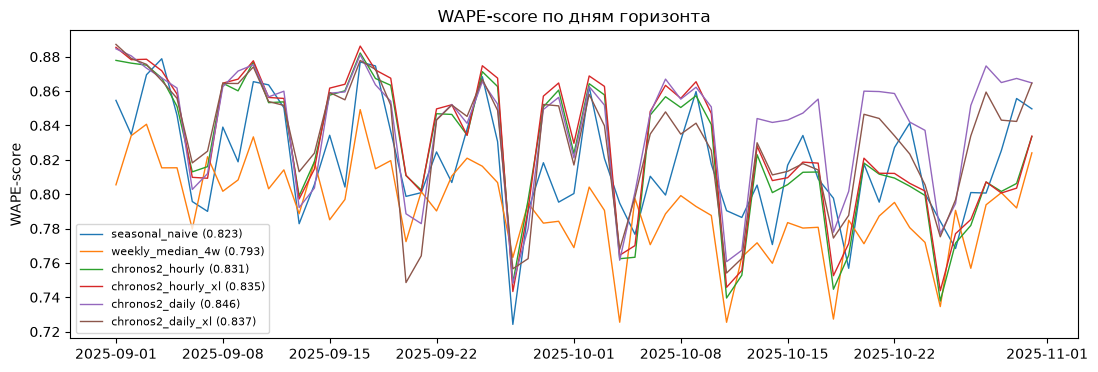

In [6]:
fig, ax = plt.subplots(figsize=(13, 4))
for name, r in results.items():
    s = daily_scores(r.preds, r.truth)
    ax.plot(s.index, s.to_numpy(), lw=1, label=f"{name} ({r.metrics['wape_score']:.3f})")
ax.set_ylabel("WAPE-score"); ax.legend(fontsize=8); ax.set_title("WAPE-score по дням горизонта")
plt.show()

## Диагностика лучшей модели

chronos2_daily 0.8461 bias -0.073 coverage_80 0.7281


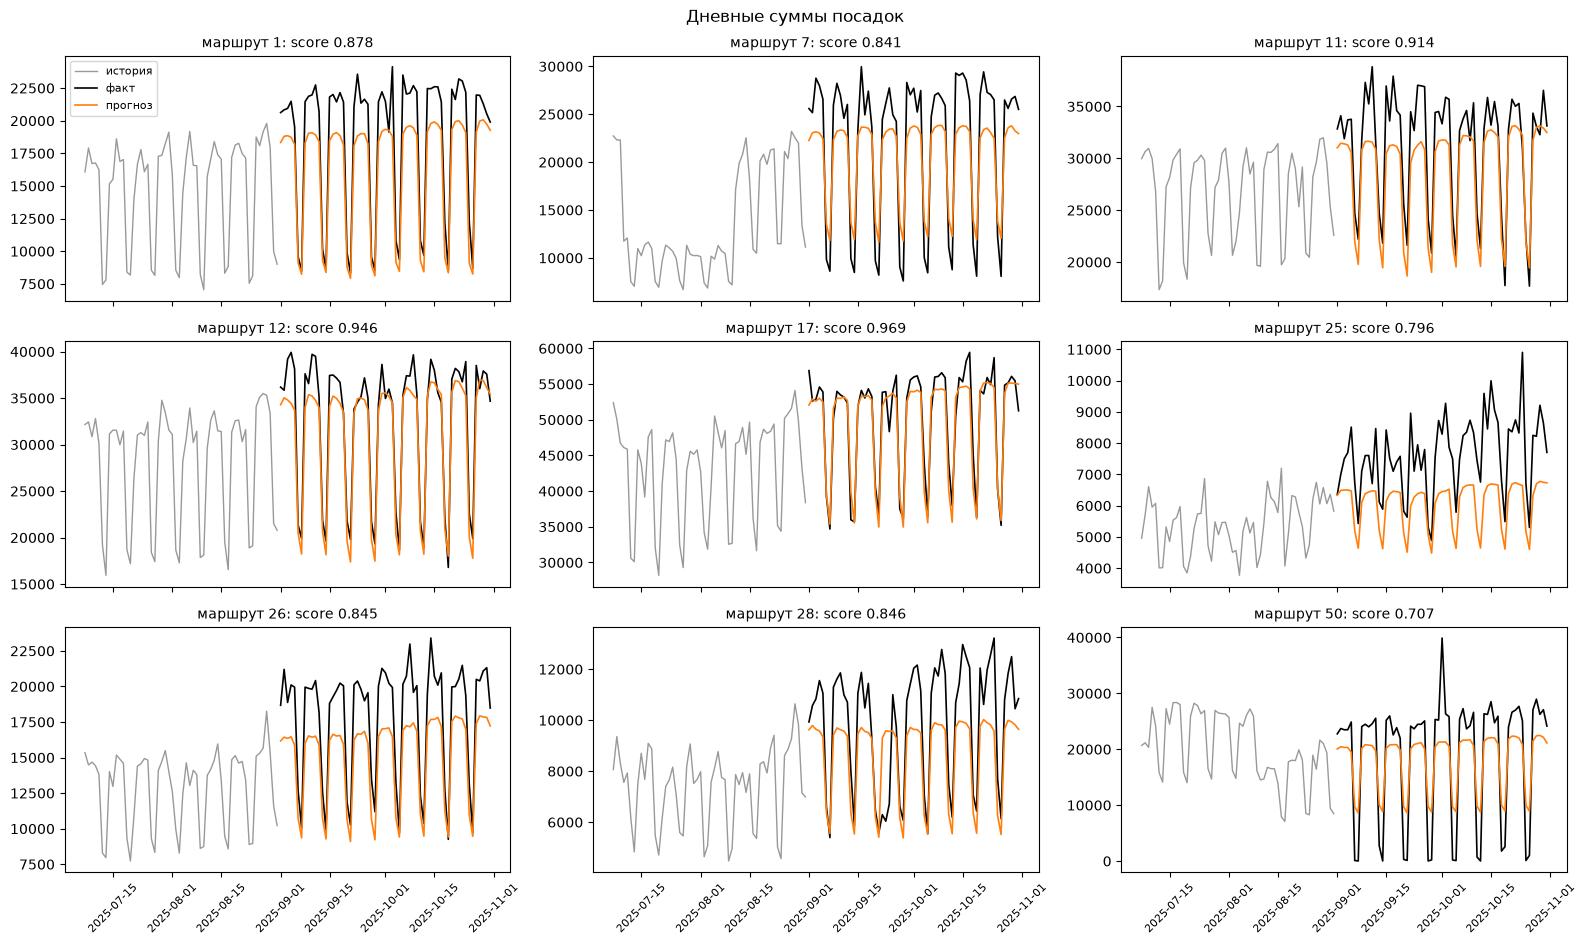

In [7]:
best = max(results, key=lambda n: results[n].metrics["wape_score"])
r = results[best]
print(best, r.metrics["wape_score"], "bias", r.metrics["bias"], "coverage_80", r.metrics.get("coverage_80"))
plots.daily_totals(r.preds, r.truth, r.history);

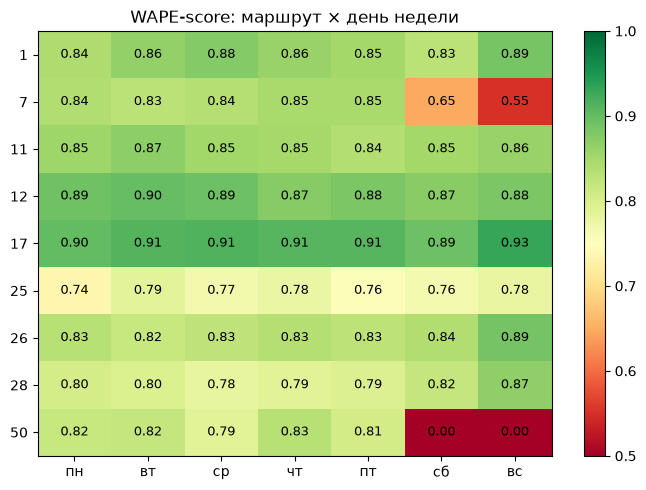

In [8]:
plots.score_heatmap(r.preds, r.truth, "dow");

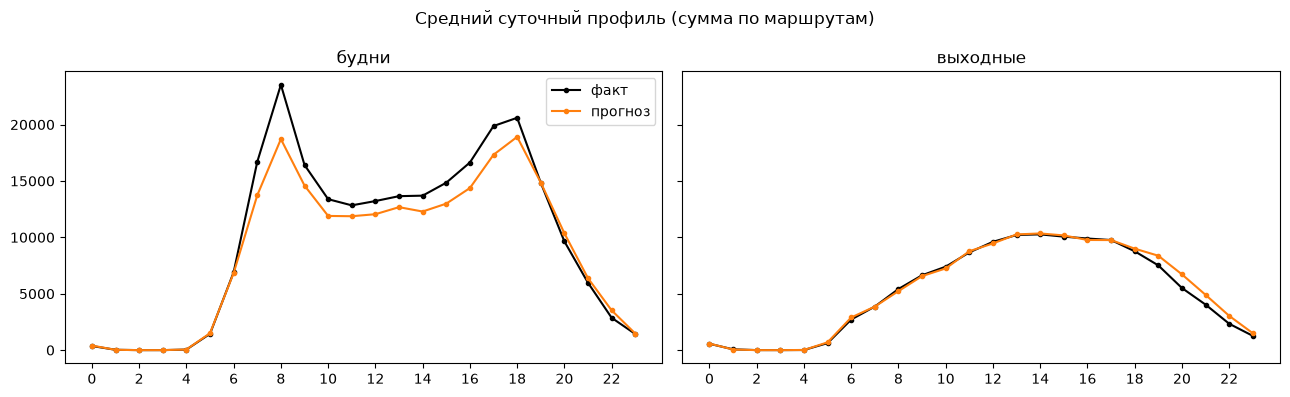

In [9]:
plots.hourly_profile(r.preds, r.truth);

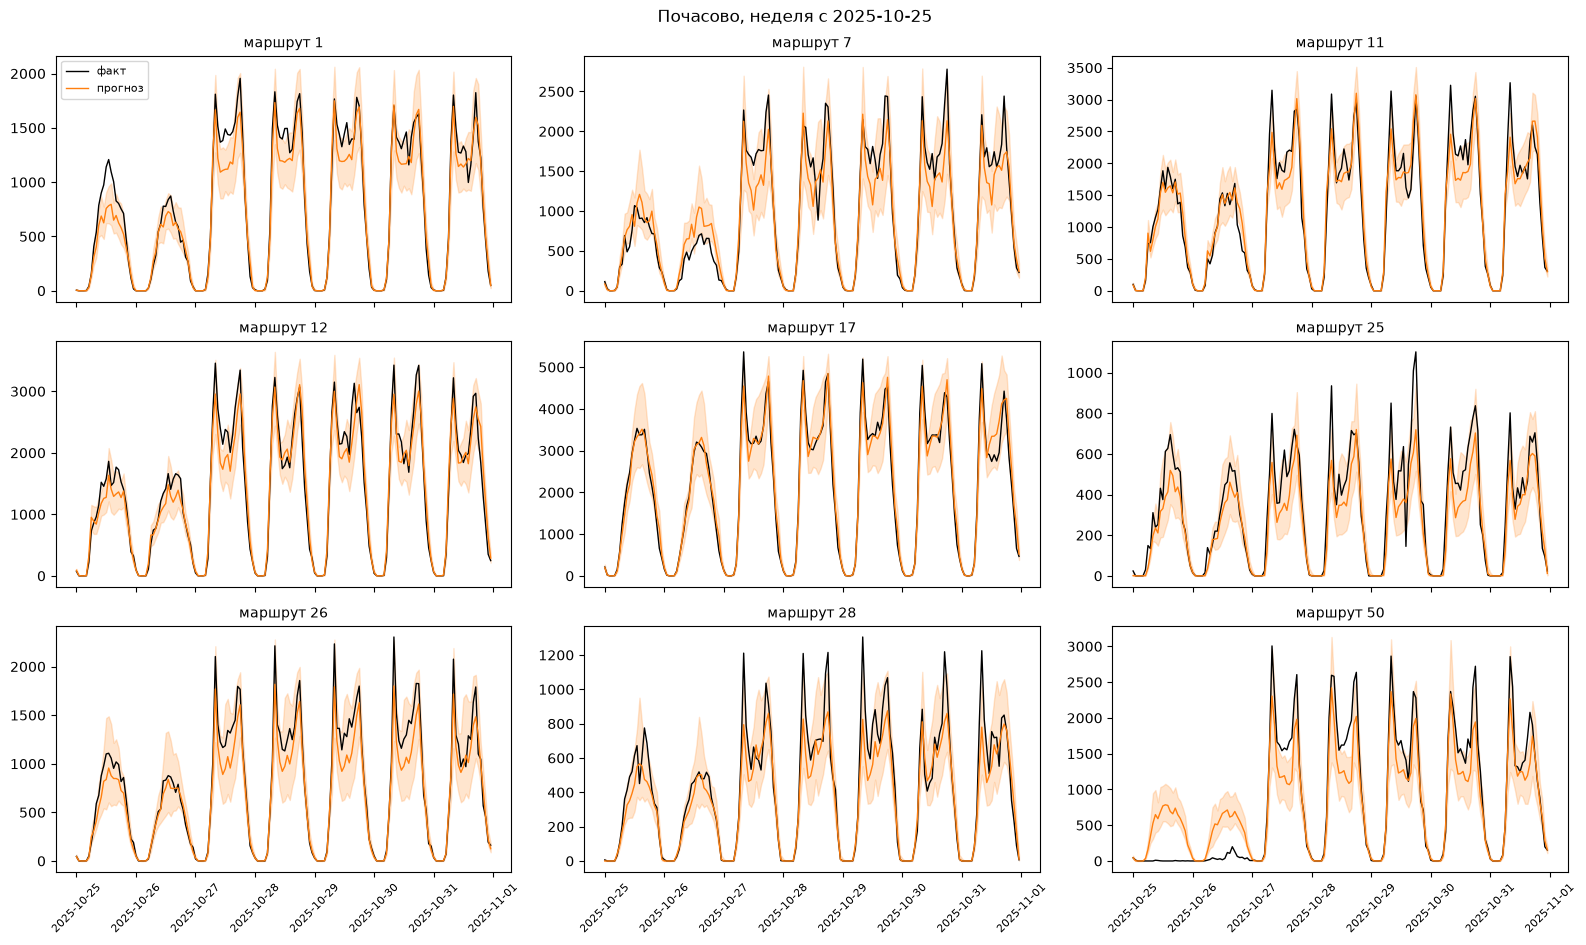

In [10]:
plots.hourly_week(r.preds, r.truth);

## Сабмишен ноябрь–декабрь лучшей моделью

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 61021.11it/s]

14640 строк, run 976c7384959e4a84a3ac76a6a3fd9213


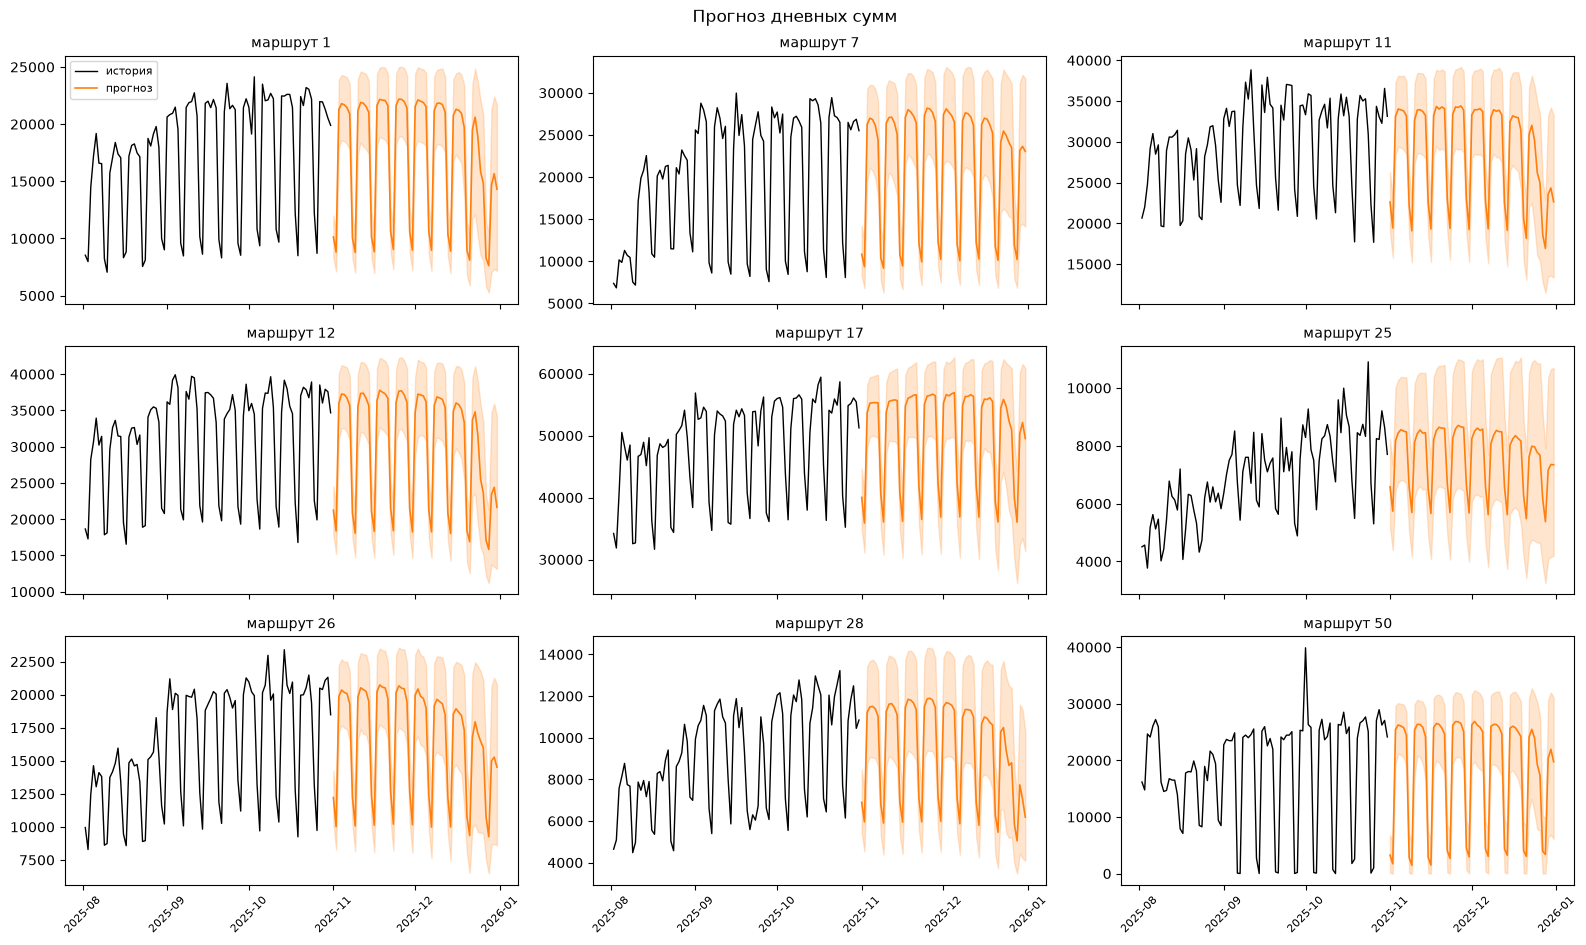

In [11]:
forecaster = build(best)
sub_preds = forecaster.fit(series).predict(SUBMISSION_START, SUBMISSION_END)
submission = to_submission(sub_preds)
sub_run_id = tracking.log_submission(forecaster, series, sub_preds, submission,
                                     backtest_run_id=run_ids[best],
                                     tags={"notebook": "01_chronos2_baseline"})
print(len(submission), "строк, run", sub_run_id)
plots.forecast_overview(sub_preds, series);

После загрузки на платформу допишите скор в run сабмишена:

In [12]:
# tracking.log_leaderboard_score(sub_run_id, 0.00)
tracking.runs_table(stage="submission")

,run_id,run,start_time,pred_total,layout,context_length,cross_learning
0,976c7384959e4a84a3ac76a6a3fd9213,submission_chronos2_route_hour_daily,2026-09-25 12:30:13.036000+00:00,12241174.0,route_hour_daily,None,False
